# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlishaYaqub/FlyRank-ML-internship-week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: which pages should an editor review first when search performance is declining, and can a simple model beat a hand-written rule at ranking them?

This supports a weekly content-review decision: out of thousands of pages, editors have limited time and need a prioritized list telling them where to look first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data: FlyRank internship warehouse, fact_content_daily_performance (month=2026-03 partition) joined with dim_content for content metadata. One row = one page on one day.

Excluded: trend_direction and trend_pct (label-derived, would leak the answer), and sessions_paid, sessions_referral, sessions_social (outside this lane's organic search focus). content_hash_id and client_hash_id are used only for joining and grouping, never as features. No client names, domains, URLs, or raw exports appear anywhere in this repo.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Target (proxy): is_declining = late_clicks < early_clicks, comparing each page's clicks in the first half of March against the second half. Observed, not hand-defined.

Features: early_clicks, early_impressions, early_avg_position, early_engaged_sessions, early_scroll_events, ctr. All computed strictly from before the March 15 cutoff.

Baseline: a hand-written rule (Week 4), tested against two signals first. Staleness verdict FALSE (flat decline rate across buckets, 0.155-0.201). CTR-vs-position mismatch verdict OPPOSITE (underperforming pages decline less, 11.2%, than at/above-average pages, 29.9%). The rule prioritizes high-impression pages with at/above-tier CTR.

Validation: split by client, not by page, since pages from the same client can share management patterns. 35 training clients, 12 test clients, zero overlap.

In [2]:
%pip -q install duckdb scikit-learn
import duckdb, pandas as pd, numpy as np
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")

agg = con.sql("""
    SELECT
        content_hash_id, client_hash_id,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_clicks ELSE 0 END) AS early_clicks,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_impressions ELSE 0 END) AS early_impressions,
        AVG(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_avg_position END) AS early_avg_position,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN ga4_engaged_sessions ELSE 0 END) AS early_engaged_sessions,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN scroll_events ELSE 0 END) AS early_scroll_events,
        SUM(CASE WHEN report_date > DATE '2026-03-15' THEN gsc_clicks ELSE 0 END) AS late_clicks
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

agg["is_declining"] = (agg["late_clicks"] < agg["early_clicks"]).astype(int)
agg["ctr"] = (agg["early_clicks"] / agg["early_impressions"].replace(0, pd.NA)).fillna(0)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(agg, groups=agg["client_hash_id"]))
train, test = agg.iloc[train_idx].copy(), agg.iloc[test_idx].copy()

features = ["early_clicks", "early_impressions", "early_avg_position", "early_engaged_sessions", "early_scroll_events", "ctr"]
X_train, y_train = train[features].fillna(0), train["is_declining"]
X_test, y_test = test[features].fillna(0), test["is_declining"]

def precision_at_k(scores, labels, k=100):
    top_k_idx = np.argsort(scores)[::-1][:k]
    return labels.iloc[top_k_idx].mean()

lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42).fit(X_train, y_train)

lr_scores = lr.predict_proba(X_test)[:, 1]
rf_scores = rf.predict_proba(X_test)[:, 1]

test["ctr_underperforming"] = test["ctr"] < test.groupby(pd.cut(test["early_avg_position"], [0,3,10,20,1000]))["ctr"].transform("mean")
baseline_score = test["early_impressions"].where(~test["ctr_underperforming"], 0)

print("Setup complete:", X_train.shape, X_test.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_1040/2455316768.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  agg["ctr"] = (agg["early_clicks"] / agg["early_impressions"].replace(0, pd.NA)).fillna(0)


Setup complete: (133474, 6) (43264, 6)


/tmp/ipykernel_1040/2455316768.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test["ctr_underperforming"] = test["ctr"] < test.groupby(pd.cut(test["early_avg_position"], [0,3,10,20,1000]))["ctr"].transform("mean")


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs baseline, same client-grouped test split, precision@100:

In [3]:
results = {
    "Random Forest": precision_at_k(rf_scores, y_test),
    "Logistic Regression": precision_at_k(lr_scores, y_test),
    "Baseline rule (Week 4)": precision_at_k(baseline_score.values, y_test),
    "Base rate (random)": y_test.mean()
}
comparison = pd.DataFrame(results.items(), columns=["Method", "Precision@100"]).sort_values("Precision@100", ascending=False)
print(comparison)

                   Method  Precision@100
0           Random Forest       0.900000
1     Logistic Regression       0.690000
2  Baseline rule (Week 4)       0.400000
3      Base rate (random)       0.191799


## 5. Limitations

*What this work cannot claim.*

This work cannot claim causation — only association. It cannot explain why a page declines, only flag that it is likely to. ctr and early_clicks together drive ~85% of the model's decisions; since is_declining is defined by comparing late_clicks to early_clicks, high-early_clicks pages mechanically have more room to "decline," so part of the model's strength may reflect this built-in relationship rather than a new business insight. The model is least reliable for very low-traffic pages (1-10 clicks), where a single click can flip the label. This slice covers one month only, so longer seasonal patterns are not visible. No claim is made about Google's ranking algorithm or causal refresh impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The ranked queue (work/outputs/baseline_action_score.csv) gives editors a directly usable priority list: review_now for top-scoring pages, monitor for mid-scoring, no_action for the rest, each with a reason code (HIGH_VALUE_AT_RISK or LOW_VOLUME_SKIP). Confidence is highest for higher-traffic pages; low-volume flagged pages warrant a lighter-touch check rather than a full rewrite commitment.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

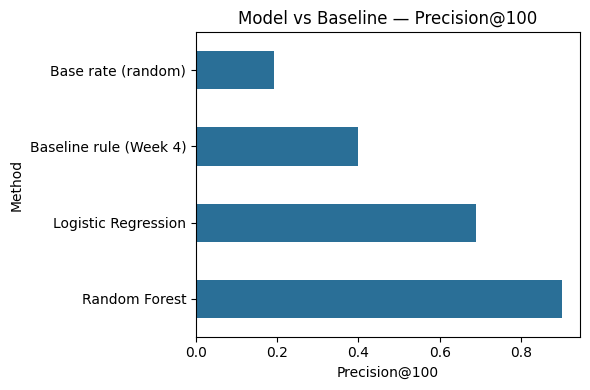

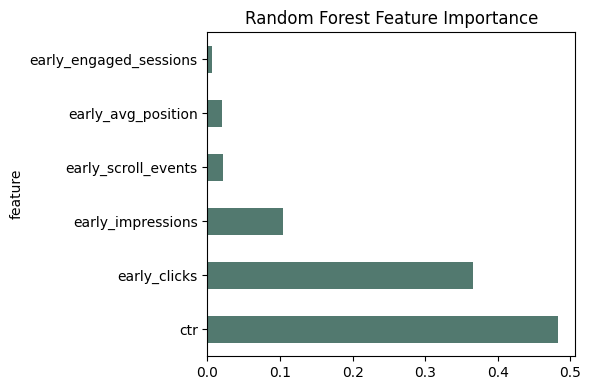

In [4]:
import matplotlib.pyplot as plt
import os
os.makedirs("work/outputs", exist_ok=True)
# Create the output directory if it doesn't exist
output_dir = "work/outputs/"
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(6,4))
comparison.plot(kind="barh", x="Method", y="Precision@100", ax=ax, legend=False, color="#2a6f97")
ax.set_xlabel("Precision@100")
ax.set_title("Model vs Baseline — Precision@100")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_vs_baseline.png"), dpi=150)
plt.show()

importances = pd.DataFrame({"feature": features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
fig2, ax2 = plt.subplots(figsize=(6,4))
importances.plot(kind="barh", x="feature", y="importance", ax=ax2, legend=False, color="#52796f")
ax2.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importance.png"), dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


### 5-minute demo outline
1. (30s) The question: which pages need review first, and does a real model beat a hand-written rule?
2. (1 min) The data and the honest baseline — two signals tested, one FALSE, one OPPOSITE of assumption.
3. (1.5 min) The model: client-grouped split, Random Forest vs Logistic Regression vs baseline.
4. (1 min) Results: 90% vs 40% vs 19% base rate — show the chart.
5. (1 min) Limitations and the ranked queue as a real editor tool.

### Social post
I built an ML model that ranks which website pages need review first when search traffic is declining. It beat a hand-written business rule by more than 2x (90% vs 40% precision on the top 100 flagged pages), using real search warehouse data and a client-grouped honest validation split. Full writeup: [paper link]

### Employer-facing summary
I built and validated a content-decline prioritization model on real production-scale search data, improving on an existing hand-written business rule from 40% to 90% precision on the highest-priority pages, using a leakage-safe, client-grouped validation design and full error analysis.